In [1]:

import anndata as ad
import celltypist
from celltypist import models
import scanpy as sc
import numpy as np
np.random.seed(12)
import os.path as op

/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [3]:
import pandas as pd
import numpy as np

def compute_dropout_rates(adata, cluster_key):
    data = adata.to_df() 
    clusters = adata.obs[cluster_key]

    dropout_df = (data == 0).groupby(clusters).mean() * 100
    
    return dropout_df



In [19]:
file_mapping = {'10x-rep2-kallisto-cellbender': '/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/SRR/kallisto/mtx_conversions/10x_rep2/10x_rep2_cellbender_filter_matrix.h5ad',
'10x-rep1-kallisto-cellbender': '/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/SRR/kallisto/mtx_conversions/10x_rep1/10x_rep1_cellbender_filter_matrix.h5ad' }

for experiment_id in file_mapping:

    output_dir = f'/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/reprocessed/{experiment_id}'
    barcode_file = op.join(output_dir, 'barcode_annotation.tsv')
    barcode_annotation = pd.read_csv(barcode_file, sep = '\t', index_col = 0)

    adata = sc.read_h5ad(file_mapping[experiment_id])
    adata = adata[:, ~adata.var.gene_symbol.isna()]
    adata.var = adata.var.reset_index()
    adata.var = adata.var.set_index("gene_symbol")
    adata.var.index = adata.var.index.astype(str)
    adata.var_names_make_unique()

    adata = adata[barcode_annotation['index']].copy()
    adata.obs['celltype_semi_manual'] = barcode_annotation.celltype_semi_manual.values
    dropout_rates = compute_dropout_rates(adata, 'celltype_semi_manual')
    select = (dropout_rates<50).sum()>0
    adata = adata[:,select].copy()
    adata.write_h5ad(op.join(output_dir, f'{experiment_id}-celltype-aware.h5ad'))
    print(adata.shape)


... storing 'celltype_semi_manual' as categorical


(10091, 2497)


... storing 'celltype_semi_manual' as categorical


(7610, 1951)


In [12]:
barcode_annotation.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       7600, 7601, 7602, 7603, 7604, 7605, 7606, 7607, 7608, 7609],
      dtype='int64', length=7610)

In [ ]:
# Normalizing to median total counts
sc.pp.normalize_total(adata, target_sum = 10000)
adata.layers['count_norm'] = adata.X.copy()
# Logarithmize the data
sc.pp.log1p(adata)
sc.tl.pca(adata, svd_solver = 'randomized', zero_center = False)
sc.pp.neighbors(adata, n_neighbors = 50)
sc.tl.umap(adata, n_components =50)



In [16]:
sc.tl.tsne(adata)


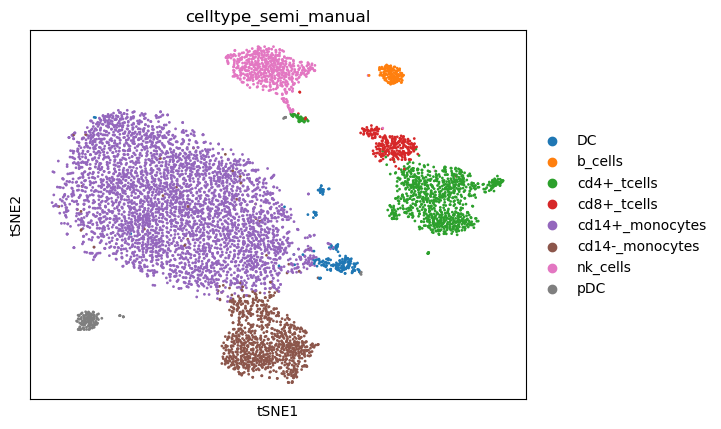

In [17]:
sc.pl.tsne(adata, color = 'celltype_semi_manual')

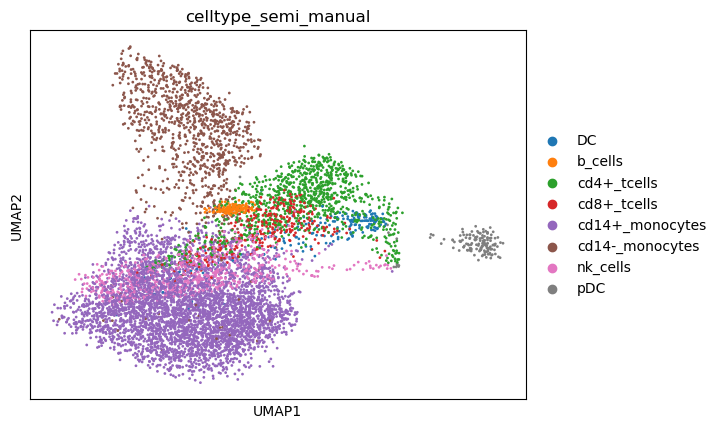

In [18]:
sc.pl.umap(adata, color = 'celltype_semi_manual')

In [21]:
file_mapping = {'bd-rhap-rep1':  '/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/rhapsody/rhapsody_out/bd-rhap-rep1',
'bd-rhap-rep2':  '/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/rhapsody/rhapsody_out/bd-rhap-rep2'
}

In [33]:
for experiment_id in file_mapping:

    output_dir = f'/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/reprocessed/{experiment_id}'
    barcode_file = op.join(output_dir, 'barcode_annotation.tsv')
    barcode_annotation = pd.read_csv(barcode_file, sep = '\t', index_col = 0)

    adata = sc.read_10x_mtx(file_mapping[experiment_id])
    adata.var_names_make_unique()
    
    print(adata.obs.index)
    print(barcode_annotation['index'])
    barcode_annotation['index'] = barcode_annotation['index'].astype(str)
    adata = adata[adata.obs.index.isin(barcode_annotation['index'])].copy()
    print(adata)
    adata.obs['celltype_semi_manual'] = barcode_annotation.celltype_semi_manual.values
    dropout_rates = compute_dropout_rates(adata, 'celltype_semi_manual')
    select = (dropout_rates<30).sum()>0
    adata = adata[:,select].copy()
    adata.write_h5ad(op.join(output_dir, f'{experiment_id}-celltype-aware.h5ad'))
    print(adata)


Index(['14150', '40095', '41585', '50404', '57895', '60039', '70380', '75691',
       '78479', '90707',
       ...
       '56562393', '56563220', '56568023', '56575542', '56579115', '56585924',
       '56588762', '56590239', '56590950', '56617035'],
      dtype='object', length=11466)
0           14150
1           40095
2           41585
3           50404
4           57895
           ...   
10920    56585924
10921    56588762
10922    56590239
10923    56590950
10924    56617035
Name: index, Length: 10925, dtype: int64
AnnData object with n_obs × n_vars = 10925 × 46998
    var: 'gene_ids', 'feature_types'


... storing 'celltype_semi_manual' as categorical
... storing 'feature_types' as categorical


AnnData object with n_obs × n_vars = 10925 × 2185
    obs: 'celltype_semi_manual'
    var: 'gene_ids', 'feature_types'
Index(['404', '5422', '16394', '25262', '41195', '44807', '47745', '47965',
       '50640', '52409',
       ...
       '56604418', '56604718', '56609955', '56610135', '56614407', '56614724',
       '56615372', '56616072', '56619568', '56620123'],
      dtype='object', length=17159)
0             404
1           41195
2           44807
3           47745
4           47965
           ...   
15028    56614724
15029    56615372
15030    56616072
15031    56619568
15032    56620123
Name: index, Length: 15033, dtype: int64
AnnData object with n_obs × n_vars = 15033 × 46335
    var: 'gene_ids', 'feature_types'


... storing 'celltype_semi_manual' as categorical
... storing 'feature_types' as categorical


AnnData object with n_obs × n_vars = 15033 × 2227
    obs: 'celltype_semi_manual'
    var: 'gene_ids', 'feature_types'


In [44]:
dropout_rates.loc[:, ['CD8A']]


,CD8A
celltype_semi_manual,
DC,98.892989
b_cells,98.989899
cd14+_monocytes,99.399501
cd14-_monocytes,99.350325
cd4+_tcells,88.562874
cd8+_tcells,24.906367
nk_cells,50.650759
pDC,98.755187
